### Autor: David Roca Tauste

---
# Estimación del precio de venta en vehículos de ocasión
---

# 1. PREPARACIÓN

## 1.1. Carga de librerías

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.calibration import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

import math

## 1.2. Carga del CSV y primeras observaciones de los datos

In [43]:
ruta = "true_car_listings.csv"
datos = pd.read_csv(ruta)

valor_objetivo = "Price"

In [44]:
print(datos.shape)
print(f"La cantidad de filas es: {datos.shape[0]}")
print(f"La cantidad de columnas es: {datos.shape[1]}")

(852122, 8)
La cantidad de filas es: 852122
La cantidad de columnas es: 8


In [45]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852122 entries, 0 to 852121
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Price    852122 non-null  int64 
 1   Year     852122 non-null  int64 
 2   Mileage  852122 non-null  int64 
 3   City     852122 non-null  object
 4   State    852122 non-null  object
 5   Vin      852122 non-null  object
 6   Make     852122 non-null  object
 7   Model    852122 non-null  object
dtypes: int64(3), object(5)
memory usage: 52.0+ MB


In [46]:
datos.describe()

,Price,Year,Mileage
count,852122.000000,852122.000000,8.521220e+05
mean,21464.100210,2013.289145,5.250779e+04
std,13596.202241,3.414987,4.198896e+04
min,1500.000000,1997.000000,5.000000e+00
25%,13000.000000,2012.000000,2.383600e+04
50%,18500.000000,2014.000000,4.025600e+04
75%,26995.000000,2016.000000,7.218600e+04
max,499500.000000,2018.000000,2.856196e+06


In [47]:
datos.head()

,Price,Year,Mileage,City,State,Vin,Make,Model
0,8995,2014,35725,El Paso,TX,19VDE2E53EE000083,Acura,ILX6-Speed
1,10888,2013,19606,Long Island City,NY,19VDE1F52DE012636,Acura,ILX5-Speed
2,8995,2013,48851,El Paso,TX,19VDE2E52DE000025,Acura,ILX6-Speed
3,10999,2014,39922,Windsor,CO,19VDE1F71EE003817,Acura,ILX5-Speed
4,14799,2016,22142,Lindon,UT,19UDE2F32GA001284,Acura,ILXAutomatic


---
# 2. LIMPIEZA DE DATOS

## 2.1. Gestión de valores nulos

In [48]:
print("Número de casillas nulas por columna:")
datos.isnull().sum()

Número de casillas nulas por columna:


Price      0
Year       0
Mileage    0
City       0
State      0
Vin        0
Make       0
Model      0
dtype: int64

## 2.2. Tipos de datos de las columnas

In [49]:
datos.dtypes

Price       int64
Year        int64
Mileage     int64
City       object
State      object
Vin        object
Make       object
Model      object
dtype: object

In [50]:
columnas_int = datos.select_dtypes(include=["int64"]).columns
columnas_object = datos.columns.drop(columnas_int)

print(columnas_int)
print(columnas_object)

Index(['Price', 'Year', 'Mileage'], dtype='object')
Index(['City', 'State', 'Vin', 'Make', 'Model'], dtype='object')


## 2.3. Gestión de anomalías (outliers)

In [51]:
columnas = datos.columns.values
print(columnas)

['Price' 'Year' 'Mileage' 'City' 'State' 'Vin' 'Make' 'Model']


In [52]:
def comprobar_outliers_boxplot(columnas_base):
    columnas_comprobar_outliers = []

    for columna_actual in columnas_base:
        if (columna_actual != valor_objetivo):
            columnas_comprobar_outliers.append(columna_actual)
        
        
    num_vars = len(columnas_comprobar_outliers)
    if num_vars == 0:
        print("No hay columnas para analizar.")
        return []

    # Cálculo de filas y columnas
    num_cols = math.ceil(math.sqrt(num_vars))
    num_rows = math.ceil(num_vars / num_cols)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 4, num_rows * 5))

    axes = axes.flatten()
    for i, var in enumerate(columnas_comprobar_outliers):
        axes[i].boxplot(datos[var], tick_labels=[var])
        axes[i].set_title(f'Distribución de {var}')
        axes[i].set_ylabel('Valores')

    for j in range(len(columnas_comprobar_outliers), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return columnas_comprobar_outliers

### 2.3.1 Validación de valores int

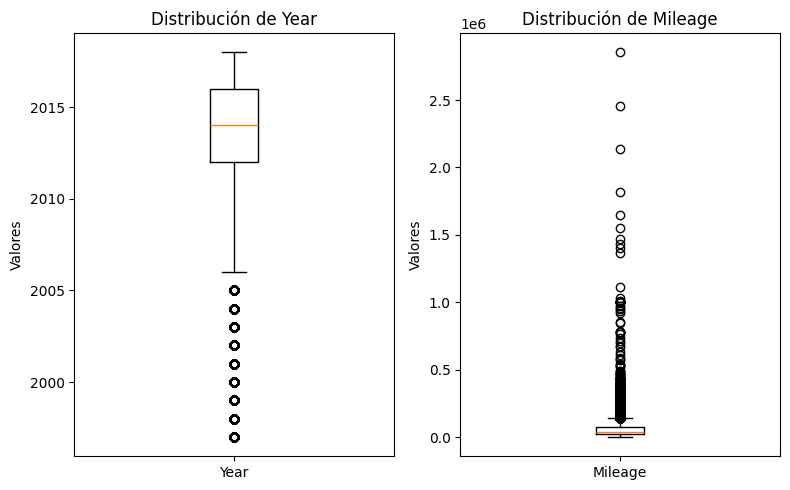

['Year', 'Mileage']

In [53]:
# Valores int
comprobar_outliers_boxplot(columnas_int)

In [54]:
datos_mileage = datos["Mileage"]

datos_mileage_descendente = datos_mileage.sort_values(ascending=False)
valores_maximos = datos_mileage_descendente[:30]

print(valores_maximos)

186465    2856196
186464    2457832
478168    2137327
429123    1814638
349757    1650780
349759    1554010
623340    1469001
349758    1428913
378930    1401471
549451    1364911
349746    1111111
186454    1033783
698018    1007008
823683    1000000
186440     999999
349720     999999
349714     999999
69149      999999
186456     999999
186445     999999
186446     999999
186449     999999
186444     999999
549453     999999
378916     999999
847015     999999
698008     999999
698022     999999
349734     999999
186447     999999
Name: Mileage, dtype: int64


In [55]:
valor_comprobacion = 999999
print((datos_mileage == valor_comprobacion).value_counts())

Mileage
False    852104
True         18
Name: count, dtype: int64


In [56]:
outliers_mileage = datos_mileage[datos_mileage > valor_comprobacion]
print(outliers_mileage)

186454    1033783
186464    2457832
186465    2856196
349746    1111111
349757    1650780
349758    1428913
349759    1554010
378930    1401471
429123    1814638
478168    2137327
549451    1364911
623340    1469001
698018    1007008
823683    1000000
Name: Mileage, dtype: int64


In [57]:
datos = datos[~datos['Mileage'].isin(outliers_mileage)]

datos_mileage = datos["Mileage"]
outliers_mileage = datos_mileage[datos_mileage > valor_comprobacion]
print(outliers_mileage)

Series([], Name: Mileage, dtype: int64)


### 2.3.2 Validación de valores object

In [58]:
for columna_actual in columnas_object:
    print(f"{datos[columna_actual].value_counts()}\n")

City
Houston         12703
San Antonio      8078
Louisville       5872
Jacksonville     5675
Austin           5297
                ...  
Los Banos           4
Pen Argyl           4
Armona              4
Port Jervis         4
Royston             2
Name: count, Length: 2553, dtype: int64

State
TX    94653
CA    80436
FL    72529
GA    39413
IL    38678
NC    37530
VA    35011
PA    28129
NY    27932
NJ    27851
OH    23259
WA    23149
CO    23004
AZ    22400
TN    19166
MA    17989
MD    17572
IN    16465
MO    16165
KY    13691
AL    13293
WI    11255
MN    10995
CT    10906
UT    10417
OR    10352
MI    10328
SC     9790
OK     9584
LA     8528
KS     7894
AR     6952
NV     6887
MS     6242
NH     5694
NE     4924
IA     4840
NM     4729
ID     3500
HI     2995
DE     2418
MT     1983
ME     1920
RI     1858
AK     1663
WV     1501
SD     1267
VT     1123
ND     1092
Fl      783
WY      610
Va      248
Md      135
Ga      109
ga      100
Az       63
Oh       52
Ca       31
DC       2

---
# 3. Ingeniería de características
## 3.1. Codificación de variables categóricas

In [59]:
datos.head()

,Price,Year,Mileage,City,State,Vin,Make,Model
0,8995,2014,35725,El Paso,TX,19VDE2E53EE000083,Acura,ILX6-Speed
1,10888,2013,19606,Long Island City,NY,19VDE1F52DE012636,Acura,ILX5-Speed
2,8995,2013,48851,El Paso,TX,19VDE2E52DE000025,Acura,ILX6-Speed
3,10999,2014,39922,Windsor,CO,19VDE1F71EE003817,Acura,ILX5-Speed
4,14799,2016,22142,Lindon,UT,19UDE2F32GA001284,Acura,ILXAutomatic


In [60]:
le = LabelEncoder()

for columna in columnas_object:
    print(columna)
    datos[columna] = le.fit_transform(datos[columna])

City
State
Vin
Make
Model


## 3.2. Selección de características

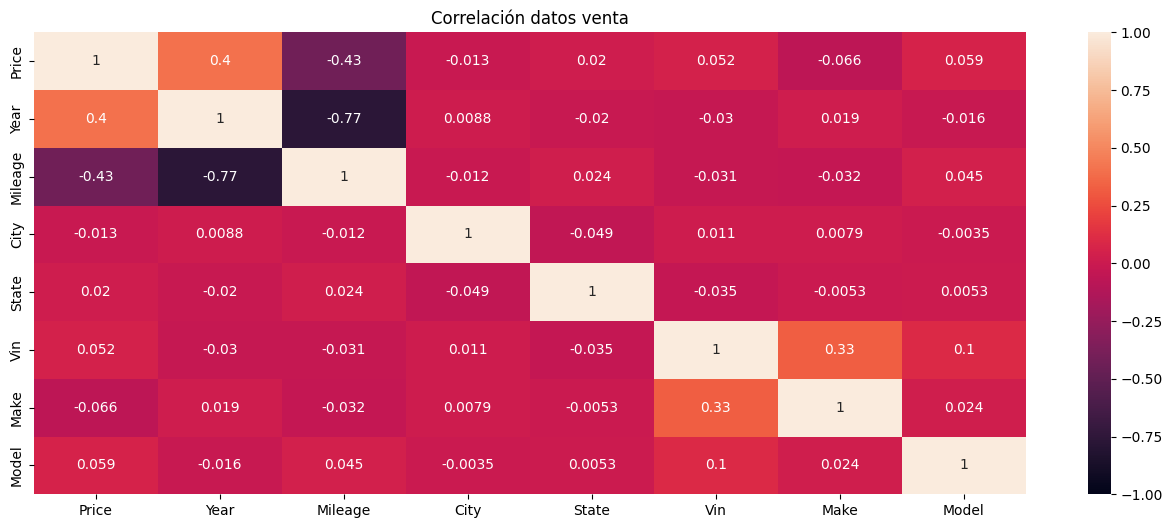

In [61]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(datos.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlación datos venta')

plt.show()

In [62]:
columnas_relevantes = list(datos.columns.drop("Vin"))

datos_relevantes = datos[columnas_relevantes]
datos_relevantes.head()

,Price,Year,Mileage,City,State,Make,Model
0,8995,2014,35725,646,49,1,1194
1,10888,2013,19606,1260,39,1,1193
2,8995,2013,48851,646,49,1,1194
3,10999,2014,39922,2490,6,1,1193
4,14799,2016,22142,1231,50,1,1196


## 3.3 Escalado

In [64]:
datos_relevantes.head()

,Price,Year,Mileage,City,State,Make,Model
0,8995,2014,35725,646,49,1,1194
1,10888,2013,19606,1260,39,1,1193
2,8995,2013,48851,646,49,1,1194
3,10999,2014,39922,2490,6,1,1193
4,14799,2016,22142,1231,50,1,1196


---
# 4. Análisis exploratorio de datos

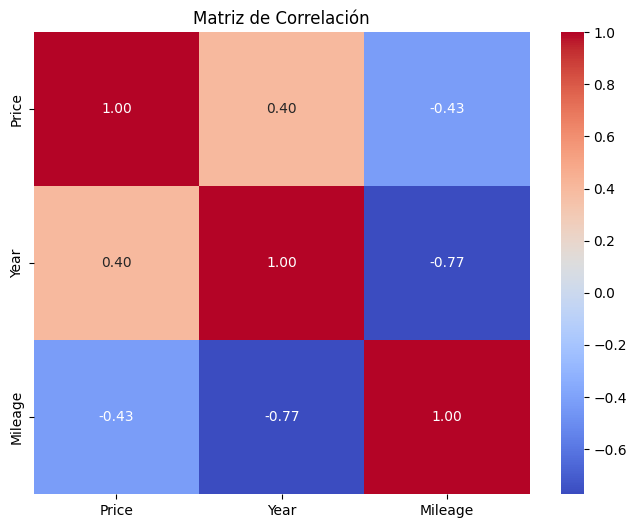

In [65]:
numerical_correlation = columnas_int

plt.figure(figsize=(8,6))
sns.heatmap(datos[numerical_correlation].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

---
# 5. Desarrollo de modelos supervisados de regresión

## 5.1. Preparación de los conjuntos train y test

In [67]:
df_train, df_val = train_test_split(datos_relevantes, test_size=0.2, random_state=12)
#columnas_relevantes.remove('Price')

In [68]:
scaler = StandardScaler()

df_train[columnas_relevantes] = scaler.fit_transform(df_train[columnas_relevantes])
df_val[columnas_relevantes] = scaler.transform(df_val[columnas_relevantes])

## 5.2. Entrenamiento y métricas de validación del modelo

### MODELO 1

In [69]:
def metrica(valores_reales, valores_predichos):
    return mean_absolute_error(valores_reales, valores_predichos)

In [70]:
modelo_arbol_decision = DecisionTreeRegressor(random_state=12, max_depth=6, min_samples_split=10)
modelo_arbol_decision.fit(df_train[columnas_relevantes], df_train[valor_objetivo])

predicciones = modelo_arbol_decision.predict(df_val[columnas_relevantes])
error_val = metrica(df_val[valor_objetivo], predicciones)

print(f'Métrica para datos de validación: {error_val}')

Métrica para datos de validación: 0.01989969795357801


In [71]:
def mostrar_metricas_arbol_decision():
    y_true = df_val[valor_objetivo]
    y_pred = predicciones

    print("MÉTRICAS:")

    # Error Absoluto Medio (MAE - Mean Absolute Error)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae}")

    # Error Cuadrático Medio (MSE - Mean Squared Error)
    mse = mean_squared_error(y_true, y_pred)
    print(f"MSE: {mse}")

    # Raíz del Error Cuadrático Medio (RMSE)
    rmse = np.sqrt(mse)
    print(f"RMSE: {rmse}")

    # Coeficiente de Determinación (R²)
    r2 = r2_score(y_true, y_pred)
    print(f"R2: {r2}")

mostrar_metricas_arbol_decision()

MÉTRICAS:
MAE: 0.01989969795357801
MSE: 0.0013308151758019652
RMSE: 0.03648033957903853
R2: 0.9987035215778685


### MODELO 2

In [72]:
if valor_objetivo in datos_relevantes.columns:
    X = datos_relevantes
    y = datos_relevantes[valor_objetivo]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
scaler = StandardScaler()

X_train[columnas_relevantes] = scaler.fit_transform(X_train[columnas_relevantes])
X_test[columnas_relevantes] = scaler.transform(X_test[columnas_relevantes])

In [74]:
modelo_arbol_aleatorio = RandomForestRegressor(n_estimators=50, max_depth=1, bootstrap=True)
modelo_arbol_aleatorio.fit(X_train, y_train)

predicciones = modelo_arbol_aleatorio.predict(X_test[columnas_relevantes])
error_val = metrica(X_test[valor_objetivo], predicciones)

print(f'Métrica para datos de validación: {error_val}')

Métrica para datos de validación: 21488.4335373407


In [75]:
def mostrar_metricas(verdades, predicciones):
    y_true = verdades
    y_pred = predicciones

    print("MÉTRICAS:")

    # Error Absoluto Medio (MAE - Mean Absolute Error)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae}")

    # Error Cuadrático Medio (MSE - Mean Squared Error)
    mse = mean_squared_error(y_true, y_pred)
    print(f"MSE: {mse}")

    # Raíz del Error Cuadrático Medio (RMSE)
    rmse = np.sqrt(mse)
    print(f"RMSE: {rmse}")

    # Coeficiente de Determinación (R²)
    r2 = r2_score(y_true, y_pred)
    print(f"R2: {r2}")

mostrar_metricas(X_test[valor_objetivo], predicciones)

MÉTRICAS:
MAE: 21488.4335373407
MSE: 553709491.8874509
RMSE: 23531.03252914013
R2: -547582889.090894


### MODELO 3

In [76]:
modelo_xgboost = XGBRegressor(max_depth=5, learning_rate=0.1, n_estimators=100, gamma=0.3)
modelo_xgboost.fit(X_train, y_train)

predicciones = modelo_xgboost.predict(X_test[columnas_relevantes])
error_val = metrica(X_test[valor_objetivo], predicciones)

print(f'Métrica para datos de validación: {error_val}')

Métrica para datos de validación: 21493.55962238238


In [77]:
mostrar_metricas(X_test[valor_objetivo], predicciones)

MÉTRICAS:
MAE: 21493.55962238238
MSE: 640679071.3424958
RMSE: 25311.63904891376
R2: -633590180.5780754


### MODELO 4

In [78]:
modelo_vecinos_cercanos = KNeighborsRegressor(n_neighbors=5, metric='euclidean', weights='uniform')
modelo_vecinos_cercanos.fit(X_train, y_train)

predicciones = modelo_vecinos_cercanos.predict(X_test[columnas_relevantes])
error_val = metrica(X_test[valor_objetivo], predicciones)

print(f'Métrica para datos de validación: {error_val}')

Métrica para datos de validación: 21426.578076200105


In [79]:
mostrar_metricas(X_test[valor_objetivo], predicciones)

MÉTRICAS:
MAE: 21426.578076200105
MSE: 640555910.6874382
RMSE: 25309.206046169016
R2: -633468382.6525748
